Starting optimization for non-sparse model...


  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_1908170/2439287060.py:101: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2255.)
  self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]
ELBO: 4692.00: 100%|██████████| 1000/1000 [00:15<00:00, 63.50it/s]


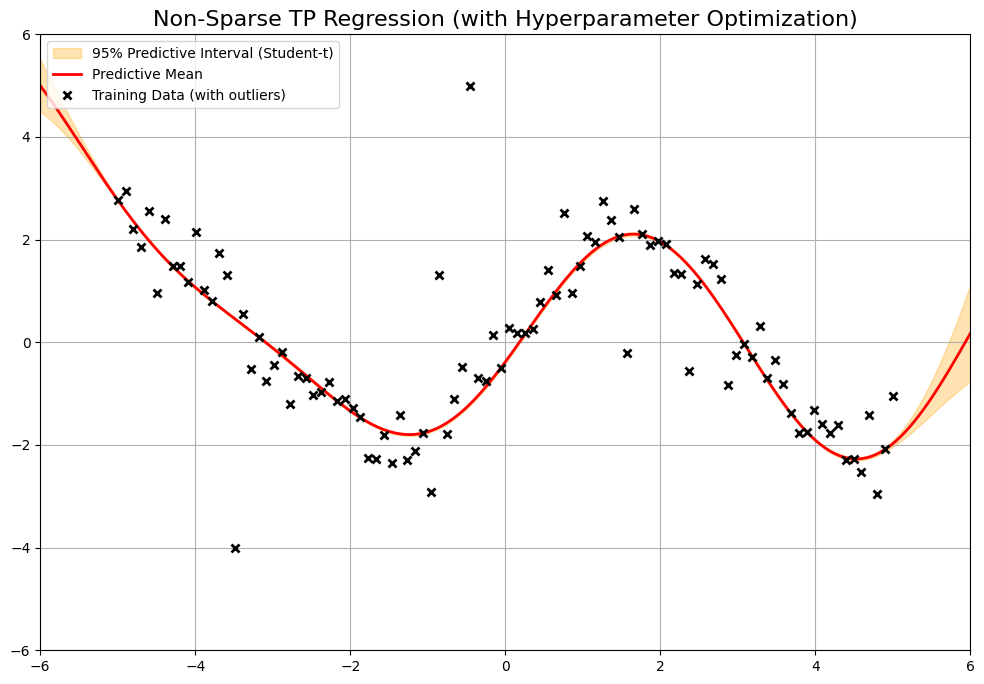

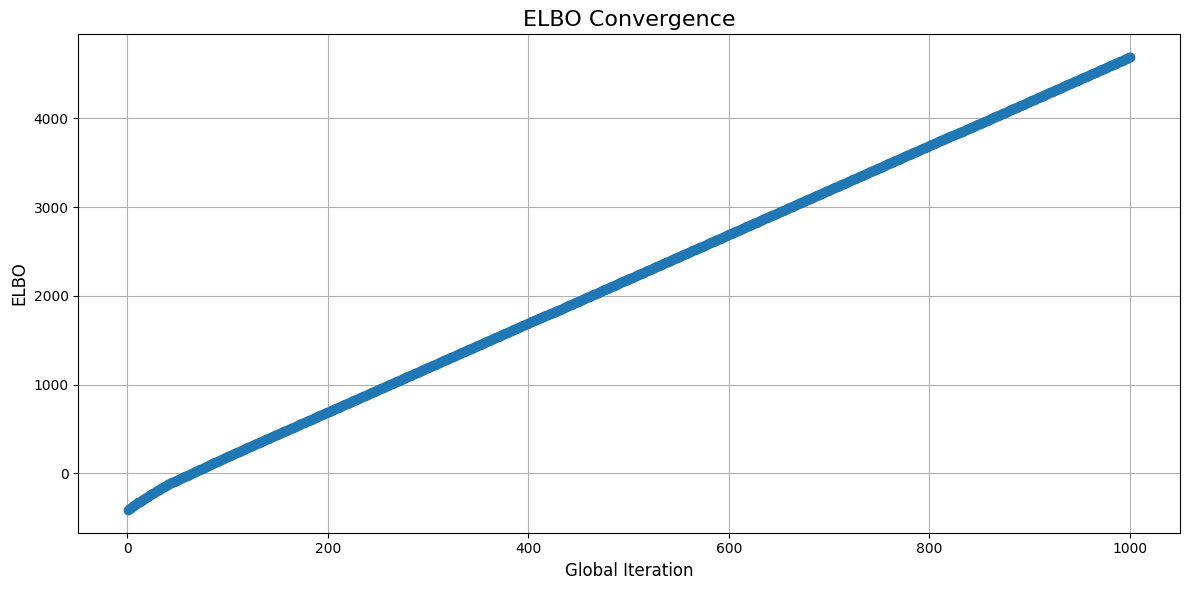

In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class NonSparseTPRegression(nn.Module):
    """
    Implements the full (non-sparse) Student-t Process regression model.
    This model works directly with the N x N kernel matrix and is suitable
    for smaller datasets due to its O(N^3) complexity.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so register as buffer
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        # These are updated via CAVI, not gradient descent, so they are not nn.Parameters.
        # q(f) = N(f | m_f, S_f), where S_f = L_f @ L_f.T
        self.m_f = torch.zeros(self.N, 1)
        self.L_f = torch.eye(self.N)

        # q(r) = Gamma(r | alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        # q(lambda_i) = Gamma(lambda_i | alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)
        E_q_f = self.m_f

        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, Lxx):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T

        # E[f^T Kxx^-1 f] = Tr(Kxx^-1 S_f) + m_f^T Kxx^-1 m_f
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        self.alpha_r = nu_f / 2.0 + self.N / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_f.squeeze()

    def _update_q_f(self, Kxx, Lxx):
        """CAVI update for q(f)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # S_f^-1 = E[r] * Kxx^-1 + diag(E[lambda]/sigma^2)
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = E_r * Kxx_inv + torch.diag(E_lambda.squeeze() / sigma_sq)
        
        # S_f = S_f_inv^-1
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]

        # m_f = S_f @ (diag(E[lambda]/sigma^2) @ y)
        temp_vec = (E_lambda / sigma_sq) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, Kxx, Lxx, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_f_old = self.m_f.clone()

            # CAVI updates
            self._update_q_lambda()
            self._update_q_r(Lxx)
            self._update_q_f(Kxx, Lxx)

            # Check for convergence
            change = torch.norm(self.m_f - m_f_old) / (torch.norm(m_f_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self, Kxx, Lxx):
        """Calculates the Evidence Lower Bound (ELBO) for the current model state."""
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)

        # --- 1. Expected Log Likelihood ---
        E_q_f = self.m_f
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for f and r ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # log q(f)
        log_q_f = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_f))) - 0.5 * self.N
        
        # log q(r)
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E[log p(f|r)]
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kxx + \
                      0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f

        # E[log p(r)]
        E_log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                    (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_f_r = log_q_f + log_q_r - E_log_p_f_r - E_log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_f_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=100, max_iter_local=10, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by alternating between CAVI updates (E-step) and
        gradient-based hyperparameter updates (M-step).
        Returns the history of ELBO values.
        """
        print("Starting optimization for non-sparse model...")
        pbar = tqdm.trange(max_iter_global)
        elbo_history = [] # ADDED: To store ELBO values

        for i in pbar:
            # Recompute Kxx and its Cholesky factor in each loop as hyperparameters change
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # E-Step: Run CAVI to update variational parameters for q(f), q(r), q(lambda)
            with torch.no_grad():
                self._cavi_step(Kxx, Lxx, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters by maximizing the ELBO
            optimizer = torch.optim.Adam(self.parameters(), lr=lr)

            for j in range(max_iter_local):
                optimizer.zero_grad()
                # Kxx and Lxx must be recomputed inside the M-step loop
                # as hyperparameters are updated by the optimizer.
                Kxx_m_step = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                Lxx_m_step = torch.linalg.cholesky(Kxx_m_step)
                neg_elbo = -self.calculate_elbo(Kxx_m_step, Lxx_m_step)
                neg_elbo.backward()
                optimizer.step()

            # ADDED: Store ELBO at the end of the global iteration for plotting
            with torch.no_grad():
                Kxx_final = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                Lxx_final = torch.linalg.cholesky(Kxx_final)
                current_elbo = self.calculate_elbo(Kxx_final, Lxx_final)
                elbo_history.append(current_elbo.item())
                pbar.set_description(f"ELBO: {current_elbo.item():.2f}")
        
        return elbo_history # ADDED: Return the history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # Predictive Mean: E[f_*] = k(X_*, X) K(X,X)^-1 m_f
            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            # --- CORRECTED Predictive Variance Calculation ---
            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            # Term 1: Var[E[f_*|f]] = k_*x Kxx^-1 S_f Kxx^-1 k_x*
            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()

            # Term 2: E[Var[f_*|f,r]] = E[r^-1] * (k_** - k_*x Kxx^-1 k_x*)
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            
            # The predictive distribution is Student-t
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=1000, max_iter_local=1, lr=0.05, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9)) # Add clamp for stability
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='o', linestyle='-')
    plt.title('ELBO Convergence', fontsize=16)
    plt.xlabel('Global Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping

    plt.show()


Starting optimization for non-sparse model...


  0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipykernel_1914564/4017340853.py:101: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2255.)
  self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]
ELBO: 49689.26: 100%|██████████| 10000/10000 [02:38<00:00, 63.19it/s]


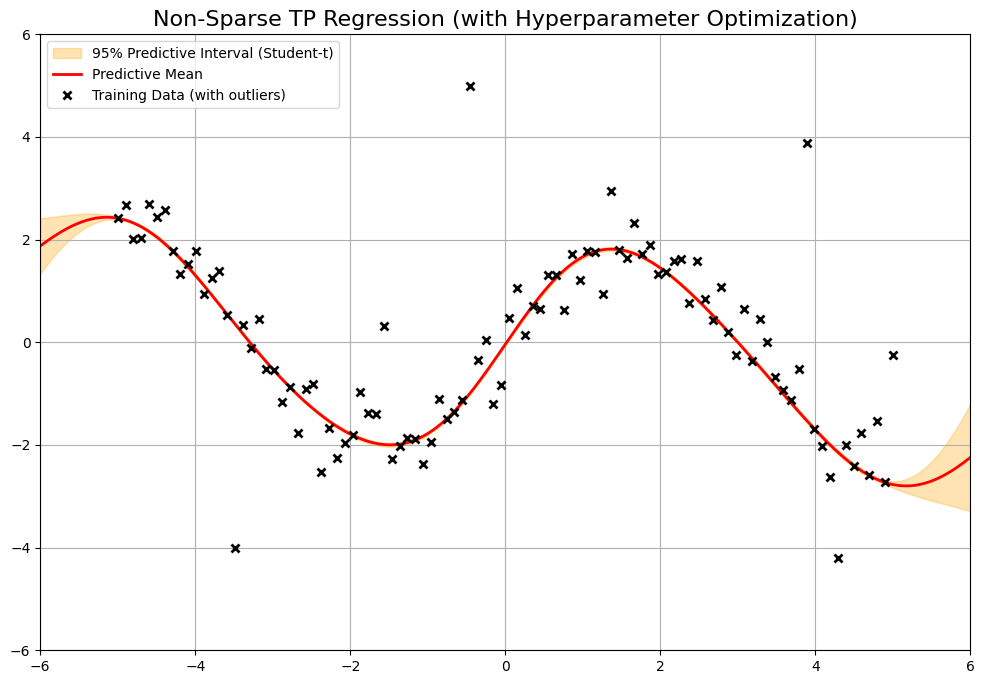

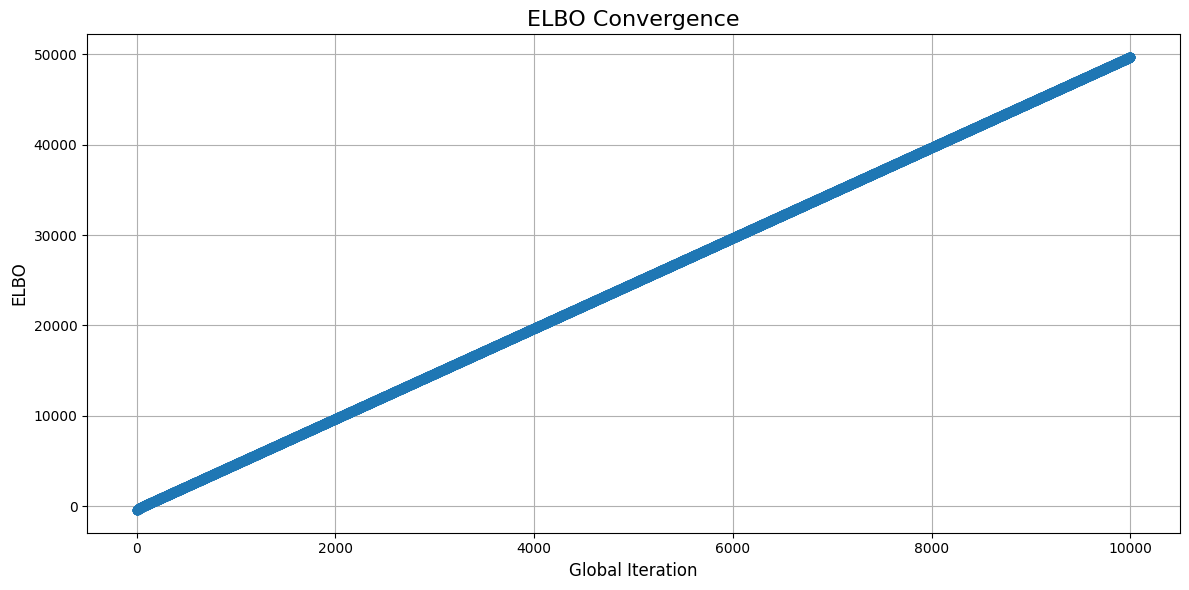

In [4]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class NonSparseTPRegression(nn.Module):
    """
    Implements the full (non-sparse) Student-t Process regression model.
    This model works directly with the N x N kernel matrix and is suitable
    for smaller datasets due to its O(N^3) complexity.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so register as buffer
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        # These are updated via CAVI, not gradient descent, so they are not nn.Parameters.
        # q(f) = N(f | m_f, S_f), where S_f = L_f @ L_f.T
        self.m_f = torch.zeros(self.N, 1)
        self.L_f = torch.eye(self.N)

        # q(r) = Gamma(r | alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        # q(lambda_i) = Gamma(lambda_i | alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)
        E_q_f = self.m_f

        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, Lxx):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T

        # E[f^T Kxx^-1 f] = Tr(Kxx^-1 S_f) + m_f^T Kxx^-1 m_f
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        self.alpha_r = nu_f / 2.0 + self.N / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_f.squeeze()

    def _update_q_f(self, Kxx, Lxx):
        """CAVI update for q(f)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # S_f^-1 = E[r] * Kxx^-1 + diag(E[lambda]/sigma^2)
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = E_r * Kxx_inv + torch.diag(E_lambda.squeeze() / sigma_sq)
        
        # S_f = S_f_inv^-1
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]

        # m_f = S_f @ (diag(E[lambda]/sigma^2) @ y)
        temp_vec = (E_lambda / sigma_sq) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, Kxx, Lxx, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_f_old = self.m_f.clone()

            # CAVI updates
            self._update_q_lambda()
            self._update_q_r(Lxx)
            self._update_q_f(Kxx, Lxx)

            # Check for convergence
            change = torch.norm(self.m_f - m_f_old) / (torch.norm(m_f_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self, Kxx, Lxx):
        """Calculates the Evidence Lower Bound (ELBO) for the current model state."""
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)

        # --- 1. Expected Log Likelihood ---
        E_q_f = self.m_f
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for f and r ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # log q(f)
        log_q_f = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_f))) - 0.5 * self.N
        
        # log q(r)
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E[log p(f|r)]
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kxx + \
                      0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f

        # E[log p(r)]
        E_log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                    (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_f_r = log_q_f + log_q_r - E_log_p_f_r - E_log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_f_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=100, max_iter_local=10, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by alternating between CAVI updates (E-step) and
        gradient-based hyperparameter updates (M-step).
        Returns the history of ELBO values.
        """
        print("Starting optimization for non-sparse model...")
        pbar = tqdm.trange(max_iter_global)
        elbo_history = [] # ADDED: To store ELBO values

        for i in pbar:
            # Recompute Kxx and its Cholesky factor in each loop as hyperparameters change
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # E-Step: Run CAVI to update variational parameters for q(f), q(r), q(lambda)
            with torch.no_grad():
                self._cavi_step(Kxx, Lxx, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters by maximizing the ELBO
            optimizer = torch.optim.Adam(self.parameters(), lr=lr)

            for j in range(max_iter_local):
                optimizer.zero_grad()
                # Kxx and Lxx must be recomputed inside the M-step loop
                # as hyperparameters are updated by the optimizer.
                Kxx_m_step = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                Lxx_m_step = torch.linalg.cholesky(Kxx_m_step)
                neg_elbo = -self.calculate_elbo(Kxx_m_step, Lxx_m_step)
                neg_elbo.backward()
                optimizer.step()

            # ADDED: Store ELBO at the end of the global iteration for plotting
            with torch.no_grad():
                Kxx_final = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                Lxx_final = torch.linalg.cholesky(Kxx_final)
                current_elbo = self.calculate_elbo(Kxx_final, Lxx_final)
                elbo_history.append(current_elbo.item())
                pbar.set_description(f"ELBO: {current_elbo.item():.2f}")
        
        return elbo_history # ADDED: Return the history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # Predictive Mean: E[f_*] = k(X_*, X) K(X,X)^-1 m_f
            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            # --- CORRECTED Predictive Variance Calculation ---
            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            # Term 1: Var[E[f_*|f]] = k_*x Kxx^-1 S_f Kxx^-1 k_x*
            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()

            # Term 2: E[Var[f_*|f,r]] = E[r^-1] * (k_** - k_*x Kxx^-1 k_x*)
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            
            # The predictive distribution is Student-t
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=10000, max_iter_local=1, lr=0.05, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9)) # Add clamp for stability
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='o', linestyle='-')
    plt.title('ELBO Convergence', fontsize=16)
    plt.xlabel('Global Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping

    plt.show()


Starting optimization with hyperparameter AND inducing point updates...


ELBO: -101.16: 100%|██████████| 50/50 [00:00<00:00, 119.67it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-5.71392799 -5.50905491 -4.98299181 -4.22968175 -3.47011671 -2.72575871
 -2.18315121 -1.60411882 -0.92376311 -0.37138609  0.16431722  0.75771915
  1.30836554  1.94116631  2.69157165  3.48808673  4.32958296  4.93724297
  5.60901271  5.84355392]
-------------------


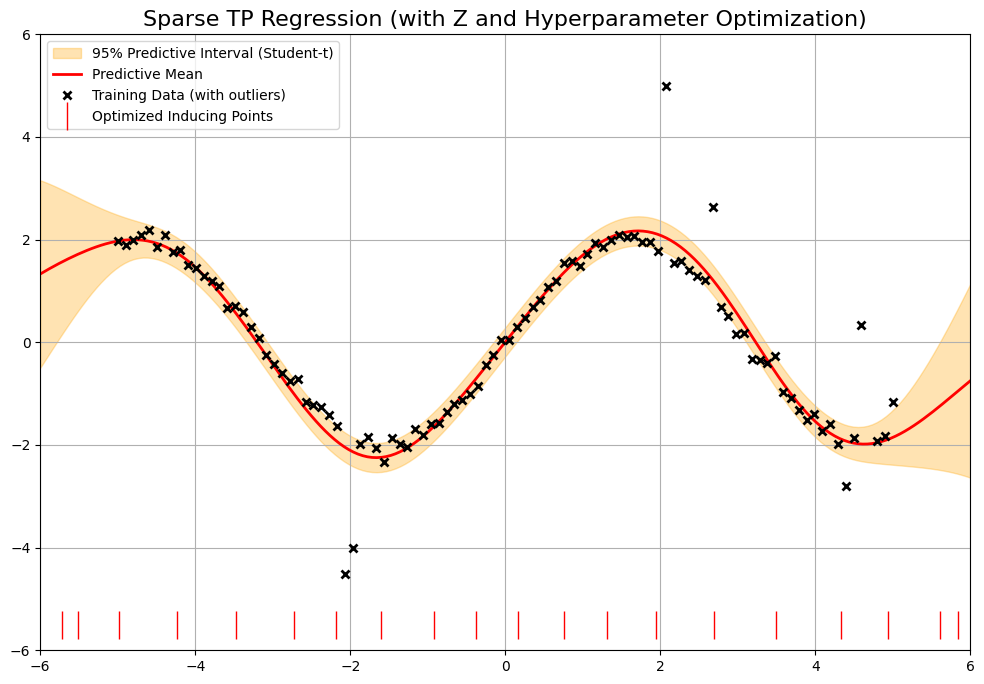

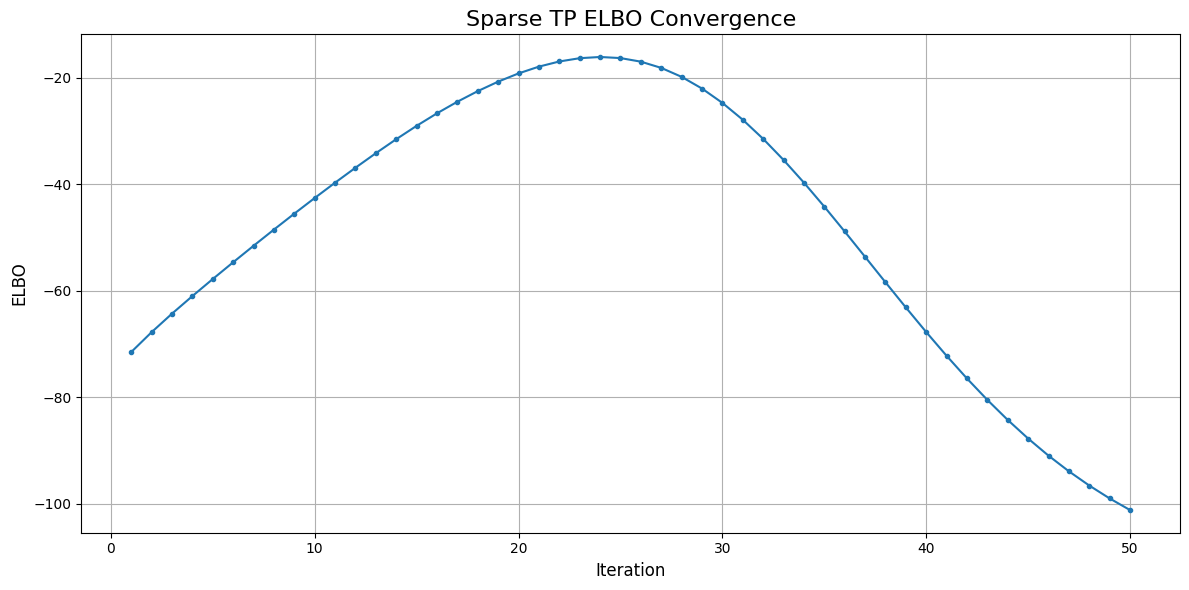

In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    """
    Implements the sparse Student-t Process regression model using inducing points.
    This is suitable for larger datasets as it avoids the O(N^3) complexity
    by working with an M x M kernel matrix, where M << N.
    """
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        # Z is now a parameter to be optimized
        self.Z = nn.Parameter(Z_initial.clone())

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters (not optimized by gradient descent, so not nn.Parameter)
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        """CAVI update for q(u)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
        S_u = Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T) # Ensure symmetry
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = Kzz @ m_u_unscaled

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # Required expectations for updates
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # CAVI updates
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        This method uses self.Z, self.X, so it's compatible with Z being a parameter.
        It's important that kernel() is called inside, as it will use the current self.Z.
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_u))) - 0.5 * self.M
        
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_det_Kzz = 2 * torch.sum(torch.log(torch.diag(Lzz)))
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kzz + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter=50, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by jointly optimizing hyperparameters and inducing points (M-step)
        and updating variational parameters (E-step).
        Returns the history of ELBO values.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        elbo_history = [] # ADDED: To store ELBO values

        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            # --- E-Step: Update variational parameters with fixed hypers/Z ---
            # K matrices are computed once before CAVI, as Z and hypers are fixed during E-step.
            with torch.no_grad():
                Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
                Lzz = torch.linalg.cholesky(Kzz)
                Kxz = self.kernel(self.X, self.Z)
                Kxx_diag = self.kernel(self.X, self.X).diag()
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            # --- M-Step: Update hyperparameters and Z by maximizing ELBO ---
            optimizer.zero_grad()
            # ELBO is calculated with current parameters (including Z) to get gradients
            neg_elbo = -self.calculate_elbo()
            neg_elbo.backward()
            optimizer.step()

            # ADDED: Store ELBO for plotting
            current_elbo = -neg_elbo.item()
            elbo_history.append(current_elbo)
            pbar.set_description(f"ELBO: {current_elbo:.2f}")
        
        return elbo_history # ADDED: Return the history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            # We use .detach() on Z as we don't want prediction to be part of the computation graph.
            Z_final = self.Z
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            # Predictive Mean
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            # Predictive Variance
            S_u = self.L_u @ self.L_u.T
            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            # Predictive degrees of freedom
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter=50, lr=0.05, cavi_max_iter=20)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


Starting optimization with hyperparameter AND inducing point updates...


ELBO: -110.94: 100%|██████████| 5000/5000 [00:32<00:00, 152.01it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-7.46983294 -7.19047861 -6.53977165 -5.72158852 -4.89766648 -4.04257934
 -3.16414416 -2.2899835  -1.41908177 -0.54512039  0.32912888  1.20495817
  2.08483059  2.9521299   3.81461913  4.67075295  5.50170717  6.30952231
  6.92300021  7.2600268 ]
-------------------


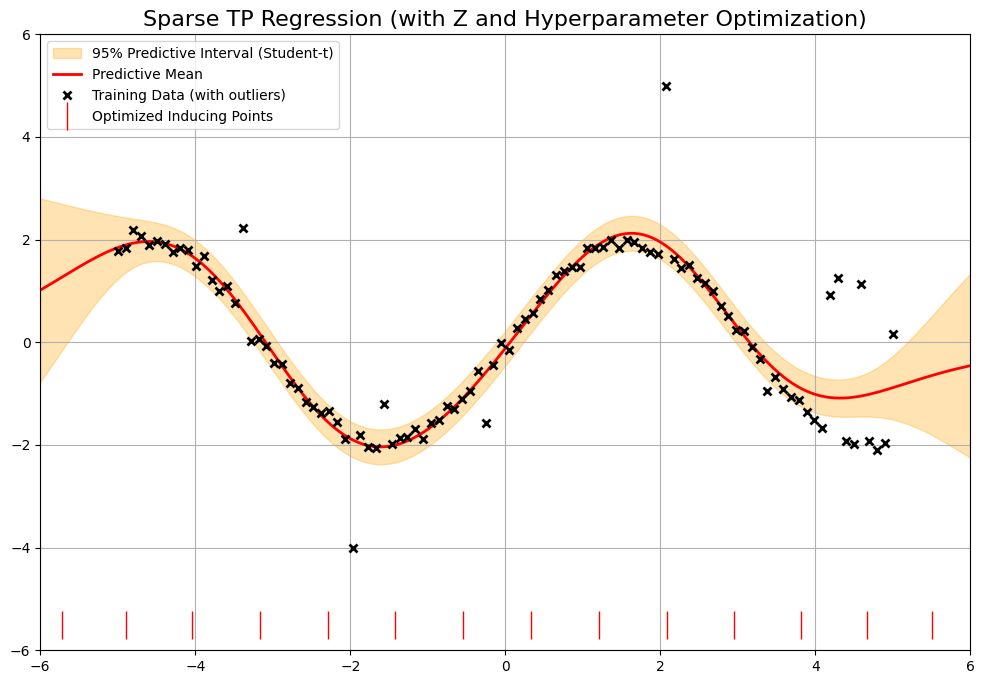

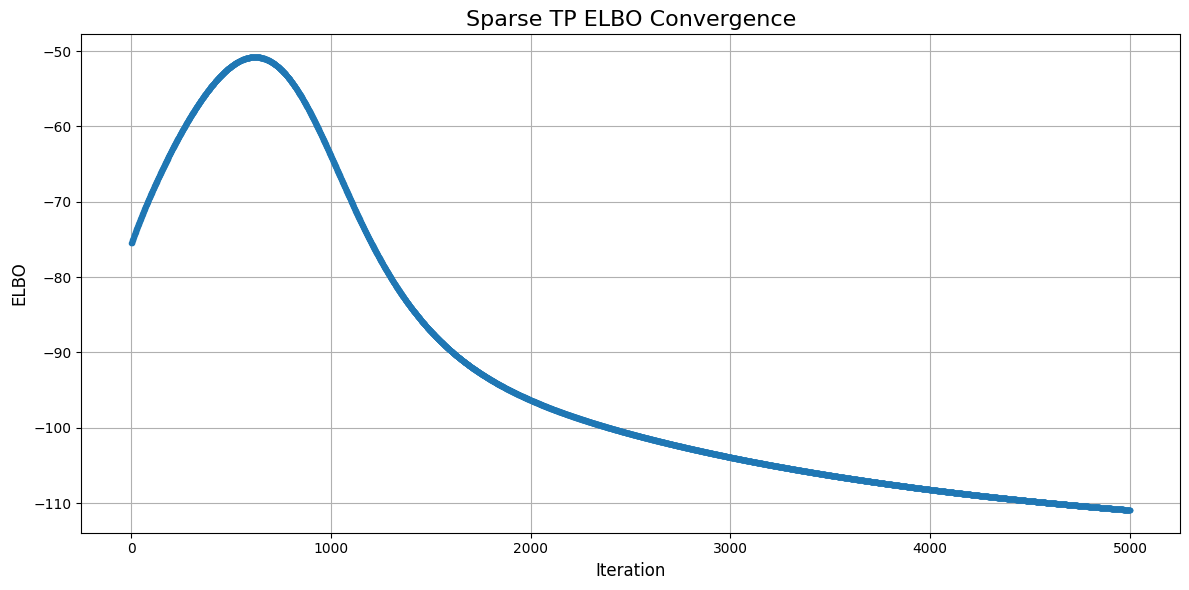

In [5]:
if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter=5000, lr=0.001, cavi_max_iter=20)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()

Starting SVI optimization...


Epoch 150/150 | Stochastic ELBO: 1443.20: 100%|██████████| 150/150 [00:04<00:00, 31.80it/s]



--- Optimized Z ---
[-5.05661162 -4.42254411 -3.75981108 -3.27573542 -2.94280407 -2.4279325
 -1.81401329 -1.11654948 -0.44730028 -0.04460933  0.04804475  0.52696503
  1.20631178  1.87551036  2.51987413  2.96285159  3.28946942  3.71847901
  4.39077037  5.02921722]
-------------------


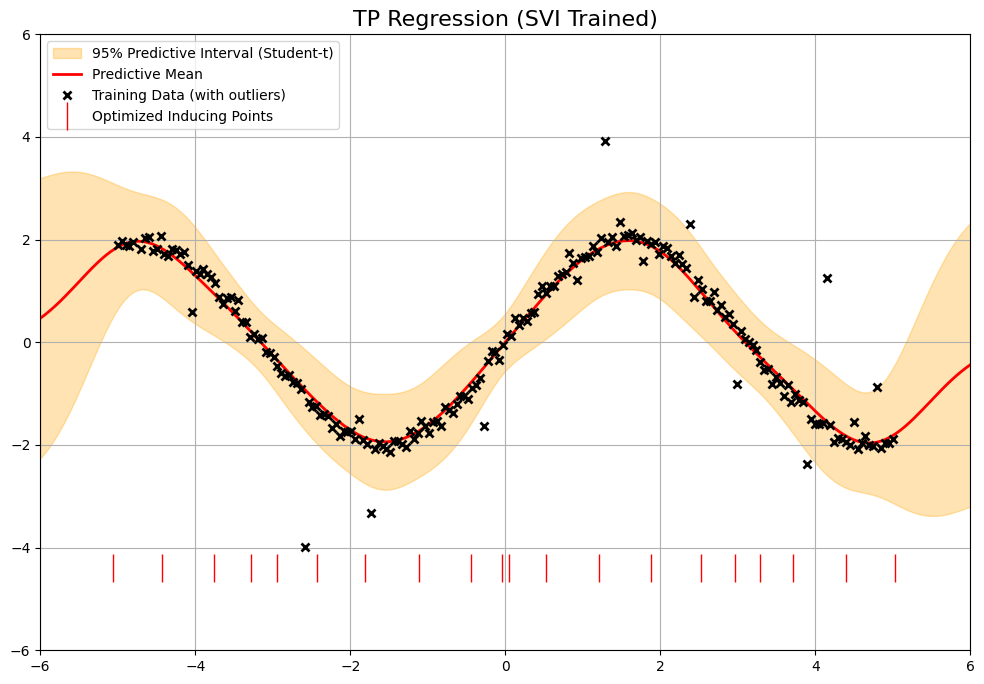

In [4]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm
from torch.utils.data import TensorDataset, DataLoader

# デフォルトのテンソル型を設定
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # データ（バッファとして登録）
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- ハイパーパラメータと誘導点をnn.Parameterとして登録 ---
        self.Z = nn.Parameter(Z_initial.clone())
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- 変分パラメータ（手動で更新するためnn.Parameterではない） ---
        self.m_u = torch.zeros(self.M, 1)
        # S_u = L_u @ L_u.T
        self.S_u = torch.eye(self.M)
        
        # グローバルパラメータ q(r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        
        # ローカルパラメータ q(lambda_i) - 全データ分を初期化
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """log変換されたパラメータから正のハイパーパラメータを取得"""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))
    
    ##############################################################
    ### SVI (Stochastic Variational Inference)用の新メソッド ###
    ##############################################################

    def fit_svi(self, epochs=100, batch_size=64, lr=0.01, rho_decay_rate=0.7):
        """
        確率的変分推論（SVI）を用いてモデルを学習させる。
        """
        print("Starting SVI optimization...")
        
        # 1. DataLoaderの準備
        dataset = TensorDataset(self.X, self.y, torch.arange(self.N))
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        # 2. ハイパーパラメータと誘導点Z用のオプティマイザ
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        
        global_step = 0
        pbar = tqdm.trange(epochs)
        
        for epoch in pbar:
            for x_batch, y_batch, batch_indices in dataloader:
                global_step += 1
                
                # 3. ステップサイズ（学習率）の決定
                # Polyak平均化のためのステップサイズ。徐々に減衰させる。
                step_size = (global_step + 10)**-rho_decay_rate

                # 4. Eステップ：変分パラメータの確率的更新
                # with torch.no_grad() は勾配計算を無効にし、手動更新の計算を高速化
                with torch.no_grad():
                    self._svi_e_step(x_batch, y_batch, batch_indices, step_size)

                # 5. Mステップ：ハイパーパラメータとZの更新
                optimizer.zero_grad()
                # 確率的ELBOを計算
                neg_stochastic_elbo = -self._calculate_stochastic_elbo(x_batch, y_batch, batch_indices)
                # 勾配を計算
                neg_stochastic_elbo.backward()
                # パラメータを更新
                optimizer.step()

                pbar.set_description(f"Epoch {epoch+1}/{epochs} | Stochastic ELBO: {-neg_stochastic_elbo.item():.2f}")

    def _svi_e_step(self, x_batch, y_batch, batch_indices, step_size):
        """
        SVIのEステップ。ミニバッチで変分パラメータを更新する。
        """
        # --- 共通計算 ---
        # detach()でZの現在の値を取得（このステップではZ自体の勾配は不要）
        Kzz = self.kernel(self.Z.detach(), self.Z.detach()) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(x_batch, self.Z.detach())

        # --- 1. ローカルパラメータ q(lambda_i) の更新 ---
        # E_q[f] と Var_q[f] をミニバッチに対して計算
        E_q_f_batch, Var_q_f_batch = self._calculate_f_expectations(Kzz, Lzz, Kxz_batch, x_batch)
        
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        
        # ミニバッチに対応する部分だけを更新
        alpha_lambda_target = nu_e / 2.0 + 0.5
        expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
        beta_lambda_target = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error
        
        self.alpha_lambda[batch_indices] = alpha_lambda_target
        self.beta_lambda[batch_indices] = beta_lambda_target
        
        # --- 2. グローバルパラメータ q(u) の更新 ---
        E_r = self.alpha_r / self.beta_r
        E_lambda_batch = self.alpha_lambda[batch_indices] / self.beta_lambda[batch_indices]
        
        # ミニバッチからターゲットとなる S_u と m_u を計算
        Psi_batch = Kxz_batch.T @ (E_lambda_batch * Kxz_batch)
        
        # 全データにスケールアップ
        scaled_Psi = (self.N / len(x_batch)) * Psi_batch

        S_u_inv_target = E_r * torch.inverse(Kzz) + scaled_Psi / sigma_sq
        S_u_target = torch.inverse(S_u_inv_target)
        S_u_target = 0.5 * (S_u_target + S_u_target.T) # 数値的安定性のため

        temp_vec_batch = (Kxz_batch.T * E_lambda_batch.T) @ y_batch
        scaled_temp_vec = (self.N / len(x_batch)) * temp_vec_batch
        m_u_target = (S_u_target @ scaled_temp_vec) / sigma_sq

        # Polyak平均化で更新
        self.S_u = (1 - step_size) * self.S_u + step_size * S_u_target
        self.m_u = (1 - step_size) * self.m_u + step_size * m_u_target
        
        # --- 3. グローバルパラメータ q(r) の更新 ---
        Kzz_inv_Su = torch.cholesky_solve(self.S_u, Lzz)
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(Kzz_inv_Su) + self.m_u.T @ Kzz_inv_mu

        _, _, _, nu_f, _ = self._get_hyperparams()
        alpha_r_target = nu_f / 2.0 + self.M / 2.0
        beta_r_target = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()
        
        # Polyak平均化で更新
        self.alpha_r = (1 - step_size) * self.alpha_r + step_size * alpha_r_target
        self.beta_r = (1 - step_size) * self.beta_r + step_size * beta_r_target
        
    def _calculate_stochastic_elbo(self, x_batch, y_batch, batch_indices):
        """
        ミニバッチを用いてELBOの不偏推定量を計算する。
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(x_batch, self.Z)
        
        # --- 1. 期待対数尤度 (ミニバッチで計算) ---
        E_q_f_batch, Var_q_f_batch = self._calculate_f_expectations(Kzz, Lzz, Kxz_batch, x_batch)
        
        E_lambda_batch = self.alpha_lambda[batch_indices] / self.beta_lambda[batch_indices]
        E_log_lambda_batch = torch.digamma(self.alpha_lambda[batch_indices]) - torch.log(self.beta_lambda[batch_indices])
        
        expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
        
        # バッチに対する対数尤度
        e_log_lik_batch = -0.5 * len(x_batch) * torch.log(torch.tensor(2 * torch.pi)) \
                        - 0.5 * len(x_batch) * torch.log(sigma_sq) \
                        + 0.5 * torch.sum(E_log_lambda_batch) \
                        - 0.5 / sigma_sq * torch.sum(E_lambda_batch * expected_sq_error)

        # --- 2. KLダイバージェンス for u and r (グローバルなので全体を計算) ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        
        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(self.S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # cholesky_solveの引数を修正
        Kzz_inv_Su = torch.cholesky_solve(self.S_u, Lzz)
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(Kzz_inv_Su) + self.m_u.T @ Kzz_inv_mu
        
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KLダイバージェンス for lambda (ミニバッチで計算) ---
        kl_lambda_batch = torch.lgamma(self.alpha_lambda[batch_indices]) - self.alpha_lambda[batch_indices] * torch.log(self.beta_lambda[batch_indices]) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda[batch_indices] - nu_e / 2) * (torch.digamma(self.alpha_lambda[batch_indices]) - torch.log(self.beta_lambda[batch_indices])) + \
                    (self.beta_lambda[batch_indices] - nu_e / 2) * (self.alpha_lambda[batch_indices] / self.beta_lambda[batch_indices])
        kl_lambda_batch_sum = torch.sum(kl_lambda_batch)

        # --- 4. 最終的な確率的ELBO ---
        # データ依存項をスケールアップして不偏推定量にする
        scaling_factor = self.N / len(x_batch)
        stochastic_elbo = scaling_factor * (e_log_lik_batch - kl_lambda_batch_sum) - kl_u_r
        
        return stochastic_elbo

    def _calculate_f_expectations(self, Kzz, Lzz, Kxz, X_in):
        """
        与えられた入力X_inに対する E[f] と Var[f] を計算するヘルパー関数
        """
        # E_q[f] = Kxz Kzz^{-1} m_u
        # cholesky_solveの引数を修正
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu
        
        # Var_q[f]
        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
        
        K_in_in_diag = self.kernel(X_in, X_in).diag()
        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ torch.linalg.cholesky(self.S_u))**2, dim=1)
        var_f_prior = E_inv_r * (K_in_in_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)
        
        return E_q_f, Var_q_f

    def predict(self, X_test):
        # 予測時には学習済みの最終パラメータを使う
        Z_final = self.Z.detach()
        K_star_z = self.kernel(X_test, Z_final)
        K_star_star_diag = self.kernel(X_test, X_test).diag()
        Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)

        # cholesky_solveの引数を修正
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        pred_mean = K_star_z @ Kzz_inv_mu

        A_star = torch.linalg.solve(Kzz, K_star_z.T).T
        
        L_u = torch.linalg.cholesky(self.S_u + torch.eye(self.M)*1e-6) # S_uからL_uを復元
        var_from_q_u = torch.sum((A_star @ L_u)**2, dim=1)

        E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
        var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

        pred_var = var_from_prior + var_from_q_u
        # 予測分布の自由度はν_fに対応
        pred_nu = 2 * self.alpha_r 

        return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. データ生成
    N = 200 # データ数を増やす
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    # 外れ値を生成
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:int(N*0.1)] # 10%を外れ値に
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    
    # 2. モデルのセットアップ
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. SVIでモデルを学習
    model.fit_svi(epochs=150, batch_size=32, lr=0.01, rho_decay_rate=0.6)

    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")
    
    # 4. 予測
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. 結果の可視化
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var)
    df = pred_nu.item()
    # 自由度が非常に小さい場合のエラーハンドリング
    if df > 0:
        lower_quantile = t.ppf(0.025, df=df)
        upper_quantile = t.ppf(0.975, df=df)
        lower = pred_mean + lower_quantile * pred_scale
        upper = pred_mean + upper_quantile * pred_scale
        plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')

    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), plt.ylim()[0] + 0.1), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('TP Regression (SVI Trained)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

Starting training for 100 epochs...


Epoch 100/100: 100%|██████████| 5/5 [00:00<00:00, 75.11it/s, BestELBO=125.50, ELBO=-406.52]



--- Finished Training ---

Best ELBO achieved: 125.4983


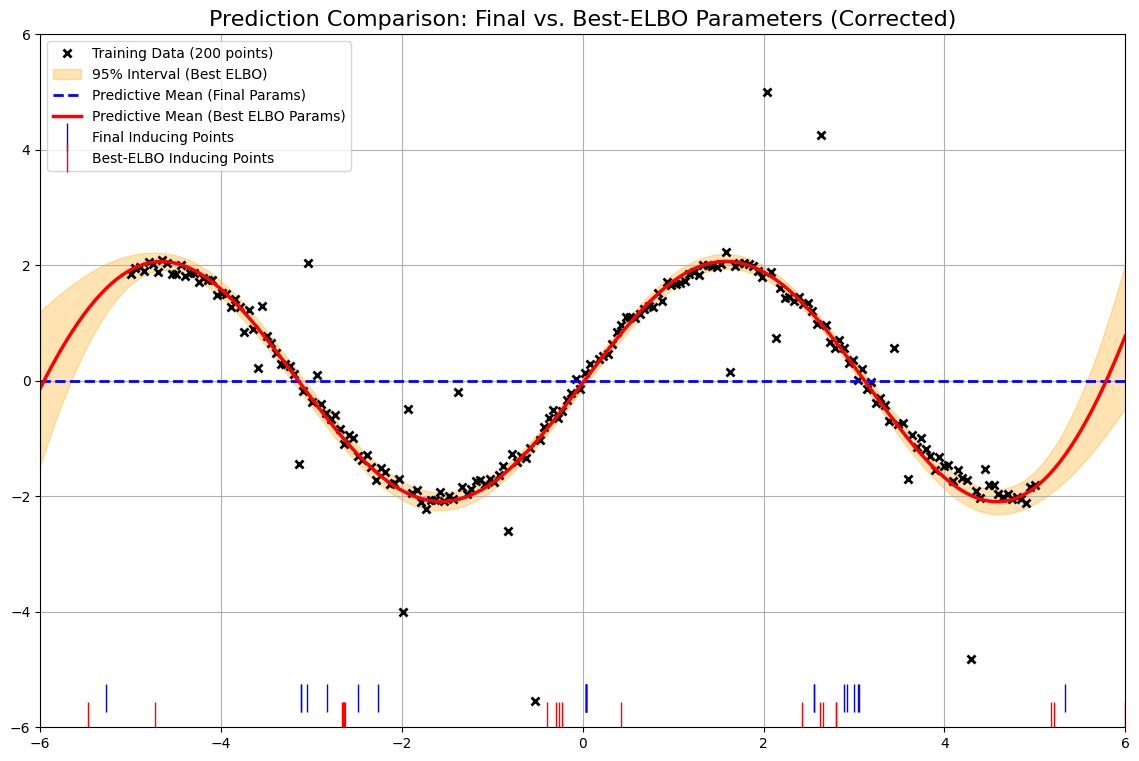

In [5]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm
import numpy as np

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class StreamingTPRegression(nn.Module):
    """
    Implements a streaming/online version of the TP Regression model.

    This version includes online optimization of all hyperparameters and inducing points.
    It supports ARD and can use the parameters corresponding to the best observed ELBO for prediction.
    """
    def __init__(self, M, D, N_total, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.M = M
        self.D = D
        self.N_total = N_total

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        self.Z = nn.Parameter(Z_initial.clone())
        
        if isinstance(kernel_lengthscale, (float, int)):
            kernel_lengthscale = torch.full((D,), float(kernel_lengthscale))
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_f - 2.0)))
        self.log_nu_e_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_e - 2.0)))

        # --- Global Variational Parameters ---
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        
        # --- State for Best ELBO Parameters ---
        self.best_elbo = -torch.inf
        self.best_params = {}

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters and inducing points from storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = 2.0 + torch.exp(self.log_nu_f_minus_2)
        nu_e = 2.0 + torch.exp(self.log_nu_e_minus_2)
        return lengthscale, variance, sigma_sq, nu_f, nu_e, self.Z

    def kernel(self, A, B):
        """ RBF kernel with ARD, uses current nn.Parameter values. """
        lengthscale, variance, _, _, _, _ = self._get_hyperparams()
        A_scaled = A / lengthscale
        B_scaled = B / lengthscale
        sq_dist = torch.cdist(A_scaled, B_scaled, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist)

    def partial_fit(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        """Performs the E-Step for a minibatch."""
        N_batch = X_batch.shape[0]
        lengthscale, variance, sigma_sq, nu_f, nu_e, Z = self._get_hyperparams()
        Kzz = self.kernel(Z, Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, Z)
        Kxx_diag_batch = variance.expand(N_batch)
        alpha_lambda_batch = torch.ones(N_batch, 1)
        beta_lambda_batch = torch.ones(N_batch, 1)
        for _ in range(cavi_max_iter):
            alpha_lambda_old = alpha_lambda_batch.clone()
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f_batch = Kxz_batch @ Kzz_inv_mu
            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
            var_f_inducing = torch.sum((A_batch @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag_batch - torch.sum(A_batch * Kxz_batch, dim=1))
            Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)
            alpha_lambda_batch = nu_e / 2.0 + 0.5
            expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
            beta_lambda_batch = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error
            if torch.norm(alpha_lambda_batch - alpha_lambda_old) < cavi_tol:
                break
        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        P_u_inv_S_u = torch.cholesky_solve(self.L_u @ self.L_u.T, Lzz)
        m_u_term = self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(P_u_inv_S_u) + m_u_term
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()
        E_r = self.alpha_r / self.beta_r
        P_u = E_r * torch.inverse(Kzz) + A_batch.T @ (E_lambda_batch * A_batch) / sigma_sq
        h_u = (A_batch.T * E_lambda_batch.T) @ y_batch / sigma_sq
        L_P = torch.linalg.cholesky(P_u + torch.eye(self.M) * 1e-6)
        S_u = torch.cholesky_solve(torch.eye(self.M), L_P)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)
        self.m_u = S_u @ h_u
        return alpha_lambda_batch, beta_lambda_batch

    def _calculate_stochastic_elbo(self, X_batch, y_batch, local_params):
        """Calculates the stochastic ELBO for the current minibatch."""
        alpha_lambda_batch, beta_lambda_batch = local_params
        N_batch = X_batch.shape[0]
        lengthscale, variance, sigma_sq, nu_f, nu_e, Z = self._get_hyperparams()
        Kzz = self.kernel(Z, Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(X_batch, Z)
        Kxx_diag = variance.expand(N_batch)
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu
        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)
        expected_sq_error = (y_batch - E_q_f).pow(2) + Var_q_f
        E_lambda = alpha_lambda_batch / beta_lambda_batch
        E_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        e_log_lik = -0.5 * N_batch * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * N_batch * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - 0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)
        scaled_e_log_lik = e_log_lik * (self.N_total / N_batch)
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + (self.alpha_r - 1) * E_log_r - self.beta_r * E_r
        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + 0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u
        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r
        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r
        kl_lambda = torch.lgamma(alpha_lambda_batch) - alpha_lambda_batch * torch.log(beta_lambda_batch) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (alpha_lambda_batch - nu_e / 2) * E_log_lambda + (beta_lambda_batch - nu_e / 2) * E_lambda
        scaled_kl_lambda = torch.sum(kl_lambda) * (self.N_total / N_batch)
        elbo = scaled_e_log_lik - kl_u_r - scaled_kl_lambda
        return elbo

    def fit(self, X_full, y_full, num_epochs=5, batch_size=20, lr=0.01, inner_loop_max_iter=5):
        """Orchestrates the training process and tracks the best parameters."""
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        num_batches = X_full.shape[0] // batch_size
        elbo_history, param_history = [], []
        
        print(f"Starting training for {num_epochs} epochs...")
        for epoch in range(num_epochs):
            permutation = torch.randperm(X_full.size(0))
            pbar = tqdm.trange(num_batches)
            pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")
            for i in pbar:
                indices = permutation[i * batch_size : (i + 1) * batch_size]
                X_batch, y_batch = X_full[indices], y_full[indices]
                for _ in range(inner_loop_max_iter):
                    with torch.no_grad():
                        local_params = self.partial_fit(X_batch, y_batch)
                    optimizer.zero_grad()
                    neg_elbo = -self._calculate_stochastic_elbo(X_batch, y_batch, local_params)
                    neg_elbo.backward()
                    optimizer.step()
                
                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                
                if current_elbo > self.best_elbo:
                    self.best_elbo = current_elbo
                    with torch.no_grad():
                        l, v, s_sq, nf, ne, Z_current = self._get_hyperparams()
                        # ## FIX ##: Save the COMPLETE model state, including variational parameters
                        self.best_params = {
                            "lengthscale": l.clone(), "variance": v.clone(), 
                            "sigma_sq": s_sq.clone(), "nu_f": nf.clone(), "nu_e": ne.clone(),
                            "inducing_points": Z_current.clone(),
                            "m_u": self.m_u.clone(), "L_u": self.L_u.clone(),
                            "alpha_r": self.alpha_r.clone(), "beta_r": self.beta_r.clone()
                        }
                
                # We still record history separately for plotting hyperparameter evolution
                with torch.no_grad():
                    l, v, s_sq, nf, ne, Z_current = self._get_hyperparams()
                    param_history.append({"lengthscale": l.clone().numpy(), "variance": v.item(), "sigma_sq": s_sq.item(),
                                          "nu_f": nf.item(), "nu_e": ne.item(), "inducing_points": Z_current.clone().numpy()})
                
                pbar.set_postfix(ELBO=f"{current_elbo:.2f}", BestELBO=f"{self.best_elbo:.2f}")
        
        return elbo_history, param_history

    def predict(self, X_test, use_best_elbo_params=False):
        """Makes predictions. Can use final parameters or best-ELBO parameters."""
        with torch.no_grad():
            if use_best_elbo_params:
                if not self.best_params:
                    raise RuntimeError("No best parameters saved. Run fit() first.")
                
                # ## FIX ##: Load the COMPLETE state from the saved dictionary
                params = self.best_params
                lengthscale, variance, nu_f = params['lengthscale'], params['variance'], params['nu_f']
                Z_pred, m_pred, L_pred = params['inducing_points'], params['m_u'], params['L_u']
                alpha_r_pred, beta_r_pred = params['alpha_r'], params['beta_r']
                
                def kernel_fn(A, B):
                    A_scaled = A / lengthscale
                    B_scaled = B / lengthscale
                    sq_dist = torch.cdist(A_scaled, B_scaled, p=2).pow(2)
                    return variance * torch.exp(-0.5 * sq_dist)
            else:
                # Use the current model parameters
                lengthscale, variance, _, nu_f, _, Z_pred = self._get_hyperparams()
                m_pred, L_pred = self.m_u, self.L_u
                alpha_r_pred, beta_r_pred = self.alpha_r, self.beta_r
                kernel_fn = self.kernel

            K_star_z = kernel_fn(X_test, Z_pred)
            K_star_star_diag = variance.expand(X_test.shape[0])
            Kzz = kernel_fn(Z_pred, Z_pred) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            Kzz_inv_mu = torch.cholesky_solve(m_pred, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_pred)**2, dim=1)

            # Use the correct E[1/r] for the chosen state
            E_inv_r = beta_r_pred / (alpha_r_pred - 1.0) if alpha_r_pred > 1 else beta_r_pred
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            pred_nu = 2 * (nu_f / 2.0 + self.M / 2.0)

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # (The main script block remains the same as your last version)
    # 1. Generate data
    N_total, D = 200, 1
    X_full = torch.linspace(-5, 5, N_total).unsqueeze(1)
    y_true = torch.sin(X_full) * 2
    noise = torch.randn(N_total, 1) * 0.1
    y_full = y_true + noise
    outlier_indices = torch.randperm(N_total)[:20]
    y_full[outlier_indices] += torch.distributions.StudentT(df=2).sample((20, 1)) * 1.5
    y_full[60], y_full[140] = -4.0, 5.0
    
    # 2. Setup model
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)
    model = StreamingTPRegression(M=M, D=D, N_total=N_total, Z_initial=Z_initial, nu_f=2.1,
                                  nu_e=2.1, kernel_lengthscale=0.5, kernel_variance=2.0,
                                  likelihood_sigma=0.5)

    # 3. Fit model
    elbo_history, param_history = model.fit(X_full, y_full, num_epochs=100, batch_size=40, lr=0.01, inner_loop_max_iter=5)

    print("\n--- Finished Training ---")
    print(f"\nBest ELBO achieved: {model.best_elbo:.4f}")

    # 4. Visualize results
    plt.figure(figsize=(14, 9))
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)

    # --- Prediction using FINAL parameters ---
    pred_mean_final, _, _ = model.predict(X_test, use_best_elbo_params=False)
    
    # --- Prediction using BEST-ELBO parameters ---
    pred_mean_best, pred_var_best, pred_nu_best = model.predict(X_test, use_best_elbo_params=True)
    pred_scale_best = torch.sqrt(pred_var_best)
    df_best = pred_nu_best.item()
    lower_best = pred_mean_best + t.ppf(0.025, df=df_best) * pred_scale_best
    upper_best = pred_mean_best + t.ppf(0.975, df=df_best) * pred_scale_best

    # Plotting
    plt.plot(X_full, y_full, 'kx', mew=2, label=f'Training Data ({N_total} points)')
    plt.fill_between(X_test.squeeze(), lower_best.squeeze(), upper_best.squeeze(), color='orange', alpha=0.3, label='95% Interval (Best ELBO)')
    plt.plot(X_test, pred_mean_final, 'b--', lw=2, label='Predictive Mean (Final Params)')
    plt.plot(X_test, pred_mean_best, 'r-', lw=2.5, label='Predictive Mean (Best ELBO Params)')
    
    Z_final = model.Z.detach().numpy()
    Z_best = model.best_params['inducing_points'].numpy()
    plt.plot(Z_final, np.full_like(Z_final, -5.5), 'b|', ms=20, label='Final Inducing Points')
    plt.plot(Z_best, np.full_like(Z_best, -5.8), 'r|', ms=20, label='Best-ELBO Inducing Points')
    
    plt.title('Prediction Comparison: Final vs. Best-ELBO Parameters (Corrected)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

Starting hyperparameter optimization...


NegLogMargLik: -205.61:  29%|██▉       | 289/1000 [00:38<01:56,  6.09it/s]

NegLogMargLik: -205.61:  29%|██▉       | 291/1000 [00:38<01:53,  6.25it/s]

NegLogMargLik: -222.58:  30%|██▉       | 296/1000 [00:39<01:50,  6.38it/s]

NegLogMargLik: -1852.53: 100%|██████████| 1000/1000 [00:44<00:00, 22.71it/s]



--- Learned Hyperparameters ---
Kernel Lengthscale: 0.122
Kernel Variance: 23649.216
Likelihood Sigma: 0.000
Prior DoF (nu_1): 0.000
Likelihood DoF (nu_2): 0.057


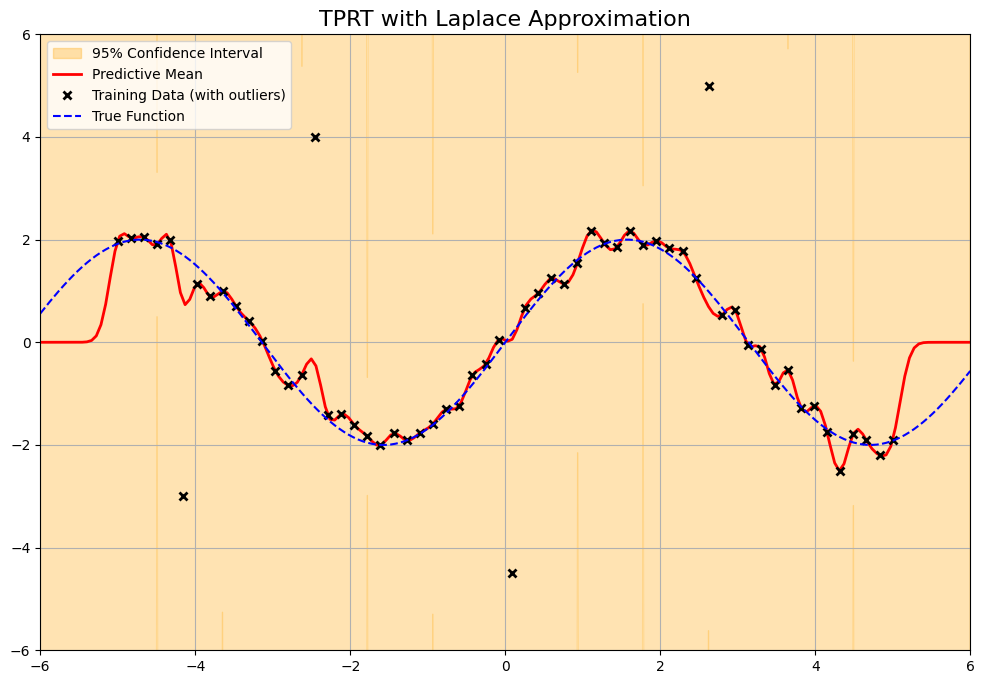

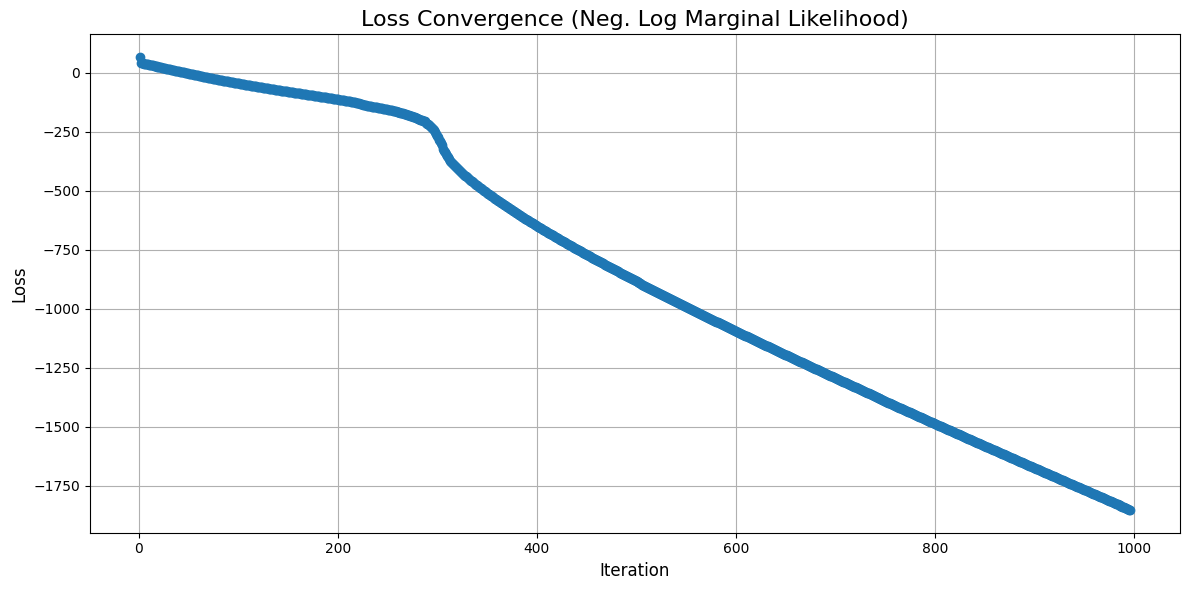

In [2]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm

# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)

class TPRT_Laplace(nn.Module):
    """
    Implements Student-t Process Regression with Student-t Likelihood (TPRT)
    using the Laplace Approximation method from Tang et al. (2017).
    """
    def __init__(self, X, y, nu_1=2.1, nu_2=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())

        self.N, self.D = X.shape

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_1 = nn.Parameter(torch.log(torch.tensor(nu_1)))
        self.log_nu_2 = nn.Parameter(torch.log(torch.tensor(nu_2)))

        # Buffer to store the mode of the latent function f
        self.register_buffer('f_hat', torch.zeros(self.N))


    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma = torch.exp(self.log_likelihood_sigma)
        nu_1 = torch.exp(self.log_nu_1)
        nu_2 = torch.exp(self.log_nu_2)
        return lengthscale, variance, sigma, nu_1, nu_2

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _calculate_ln_Q(self, f, K_inv, hyperparams):
        """Calculates the unnormalized posterior log density ln Q(f) = ln p(y|f) + ln p(f)."""
        _, _, sigma, nu_1, nu_2 = hyperparams
        # Log-likelihood term
        log_lik_term = ((nu_2 + 1) / 2) * torch.log(1 + (1 / nu_2) * ((self.y - f) / sigma).pow(2))
        # Log-prior term
        fT_K_inv_f = f @ K_inv @ f
        log_prior_term = ((nu_1 + self.N) / 2) * torch.log(1 + (1 / nu_1) * fT_K_inv_f)
        return torch.sum(log_lik_term) + log_prior_term

    def _find_f_hat(self, K_inv_detached, hyperparams_detached, max_iter=10, tol=1e-5):
        """
        Inner loop to find the mode f_hat for fixed, DETACHED hyperparameters using L-BFGS.
        This optimization is performed on a detached graph.
        """
        f = nn.Parameter(self.f_hat.clone())
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")

        def closure():
            optimizer.zero_grad()
            loss = self._calculate_ln_Q(f, K_inv_detached, hyperparams_detached)
            loss.backward()
            return loss

        for _ in range(max_iter):
            f_old = f.clone().detach()
            optimizer.step(closure)
            if torch.norm(f.detach() - f_old) < tol:
                break
        
        return f.detach()

    def _calculate_neg_log_marginal_likelihood(self):
        """
        Calculates the loss (negative log marginal likelihood) for hyperparameter optimization.
        This function builds the computation graph for the outer optimization loop.
        """
        hyperparams = self._get_hyperparams()
        _, _, sigma, nu_1, nu_2 = hyperparams

        # 1. Compute Kernel (this is part of the main computation graph)
        K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)

        # 2. Find the mode f_hat using a detached graph to prevent gradients from flowing
        #    through the inner optimization loop.
        with torch.no_grad():
            K_inv_detached = K_inv.detach()
            hyperparams_detached = tuple(p.detach() for p in hyperparams)
            f_hat = self._find_f_hat(K_inv_detached, hyperparams_detached)
            self.f_hat.copy_(f_hat) # Update buffer without creating a graph connection

        # --- Graph construction for the outer loop starts here ---
        # 3. Calculate ln(Q) at f = f_hat. This is connected to the graph via K_inv and hyperparams.
        ln_Q_at_f_hat = self._calculate_ln_Q(f_hat, K_inv, hyperparams)

        # 4. Calculate the Negative Hessian of ln(Q) at f_hat, denoted A_inv in the paper.
        f_hat_T_K_inv_f_hat = f_hat @ K_inv @ f_hat
        prior_hess_num = K_inv * (nu_1 + f_hat_T_K_inv_f_hat) - 2 * (K_inv @ torch.outer(f_hat, f_hat) @ K_inv)
        prior_hess_den = (nu_1 + f_hat_T_K_inv_f_hat)**2
        prior_hess = (nu_1 + self.N) * (prior_hess_num / prior_hess_den)

        err = self.y - f_hat
        lik_hess_num = err.pow(2) - nu_2 * sigma**2
        lik_hess_den = (err.pow(2) + nu_2 * sigma**2)**2
        W_diag = -(nu_2 + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag)
        A_inv = prior_hess + W

        # 5. Calculate log|B|, where B = K + A
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A_inv = torch.linalg.slogdet(A_inv)
        if sign.item() <= 0:
            # If Hessian is not positive definite, return a large loss
            return torch.tensor(float('inf'))

        log_det_B = log_det_K + log_det_A_inv

        # 6. Calculate constant terms from the marginal likelihood formula
        c_nu_1_term = torch.lgamma((nu_1 + self.N)/2) - torch.lgamma(nu_1/2) - (self.N/2)*torch.log(nu_1*math.pi)
        c_nu_2_term = self.N * (torch.lgamma((nu_2 + 1)/2) - torch.lgamma(nu_2/2) - 0.5*torch.log(nu_2*math.pi))
        c_sigma_term = -self.N * torch.log(sigma)

        # Combine all terms to get the final negative log marginal likelihood
        neg_log_marginal_lik = ln_Q_at_f_hat - 0.5 * log_det_B - (c_nu_1_term + c_nu_2_term + c_sigma_term)
        
        return neg_log_marginal_lik

    def fit(self, max_iter=100, lr=0.01):
        """
        Fits the model by minimizing the negative log marginal likelihood.
        Returns the history of the loss.
        """
        print("Starting hyperparameter optimization...")
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)
        loss_history = [] # ADDED: To store loss values

        for i in pbar:
            optimizer.zero_grad()
            loss = self._calculate_neg_log_marginal_likelihood()
            
            if torch.isinf(loss) or torch.isnan(loss):
                print(f"Warning: Loss is {loss.item()} at iteration {i}, skipping step.")
                # Optionally, revert to previous good parameters or reduce learning rate
                continue

            loss.backward()
            optimizer.step()
            
            loss_history.append(loss.item()) # ADDED: Store loss
            pbar.set_description(f"NegLogMargLik: {loss.item():.2f}")
        
        return loss_history # ADDED: Return history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            hyperparams = self._get_hyperparams()
            _, _, sigma, nu_1, nu_2 = hyperparams
            f_hat = self.f_hat

            # Precompute kernels
            K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()

            # Predictive mean
            pred_mean = K_star_x @ K_inv @ f_hat

            # Predictive variance
            f_hat_T_K_inv_f_hat = f_hat @ K_inv @ f_hat
            prior_hess_num = K_inv * (nu_1 + f_hat_T_K_inv_f_hat) - 2 * (K_inv @ torch.outer(f_hat, f_hat) @ K_inv)
            prior_hess_den = (nu_1 + f_hat_T_K_inv_f_hat)**2
            prior_hess = (nu_1 + self.N) * (prior_hess_num / prior_hess_den)
            
            err = self.y - f_hat
            lik_hess_num = err.pow(2) - nu_2 * sigma**2
            lik_hess_den = (err.pow(2) + nu_2 * sigma**2)**2
            W = torch.diag(-(nu_2 + 1) * (lik_hess_num / lik_hess_den))
            A_inv = prior_hess + W
            
            try:
                # Invert the negative Hessian to get the covariance matrix A
                L_A_inv = torch.linalg.cholesky(A_inv)
                A = torch.cholesky_inverse(L_A_inv)
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Using pseudo-inverse.")
                A = torch.linalg.pinv(A_inv)

            K_inv_k_star = torch.cholesky_solve(K_star_x.T, L)
            prior_var_reduction = (K_star_x * K_inv_k_star.T).sum(dim=1)
            posterior_uncertainty = (K_star_x @ K_inv @ A @ K_inv @ K_star_x.T).diag()
            
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9) # Ensure variance is non-negative
            
            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true + noise
    
    # Add significant outliers
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup the TPRT_Laplace model
    model = TPRT_Laplace(
        X=X_train,
        y=y_train,
        nu_1=2.1,
        nu_2=2.1,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model hyperparameters and get loss history
    # MODIFIED: Capture the returned loss_history
    loss_history = model.fit(max_iter=1000, lr=0.01)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    # Using Gaussian assumption for confidence interval visualization
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title('TPRT with Laplace Approximation', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    l, v, s, n1, n2 = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {l.item():.3f}")
    print(f"Kernel Variance: {v.item():.3f}")
    print(f"Likelihood Sigma: {s.item():.3f}")
    print(f"Prior DoF (nu_1): {n1.item():.3f}")
    print(f"Likelihood DoF (nu_2): {n2.item():.3f}")
    
    # 6. ADDED: Visualize Loss (Negative Log Marginal Likelihood) history
    if loss_history: # Only plot if training happened
        plt.figure(figsize=(12, 6))
        plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', linestyle='-')
        plt.title('Loss Convergence (Neg. Log Marginal Likelihood)', fontsize=16)
        plt.xlabel('Iteration', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.grid(True)
        plt.tight_layout()

    plt.show()


Starting hyperparameter optimization...


NegLogMargLik: -44.20: 100%|██████████| 100/100 [00:13<00:00,  7.31it/s]



--- Learned Hyperparameters ---
Kernel Lengthscale: 0.826
Kernel Variance: 2.728
Likelihood Sigma: 0.195
Prior DoF (nu_1): 0.774
Likelihood DoF (nu_2): 1.433


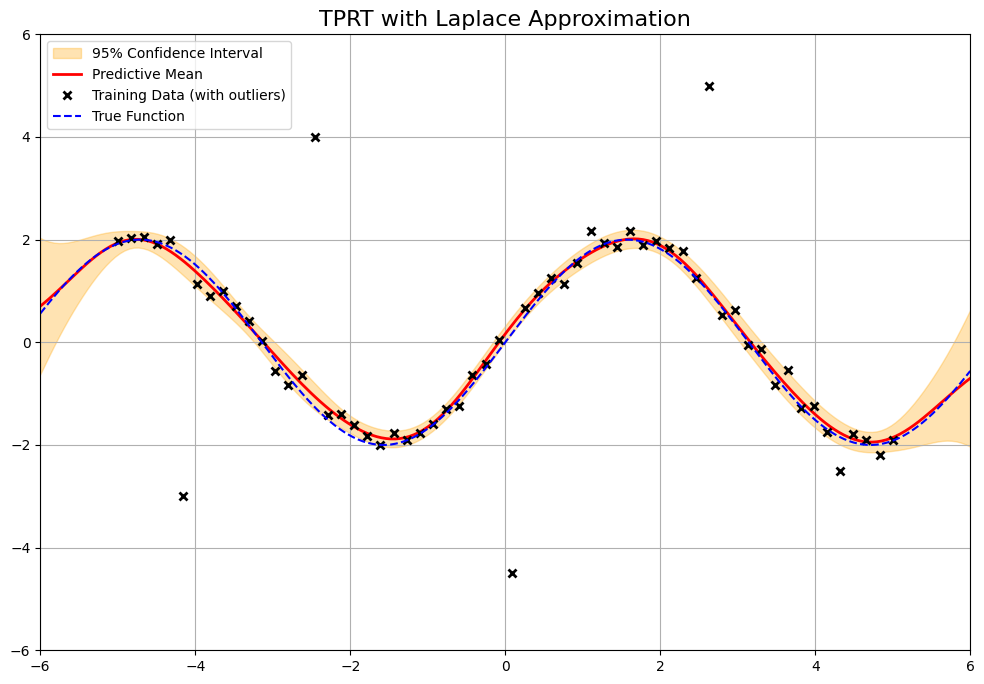

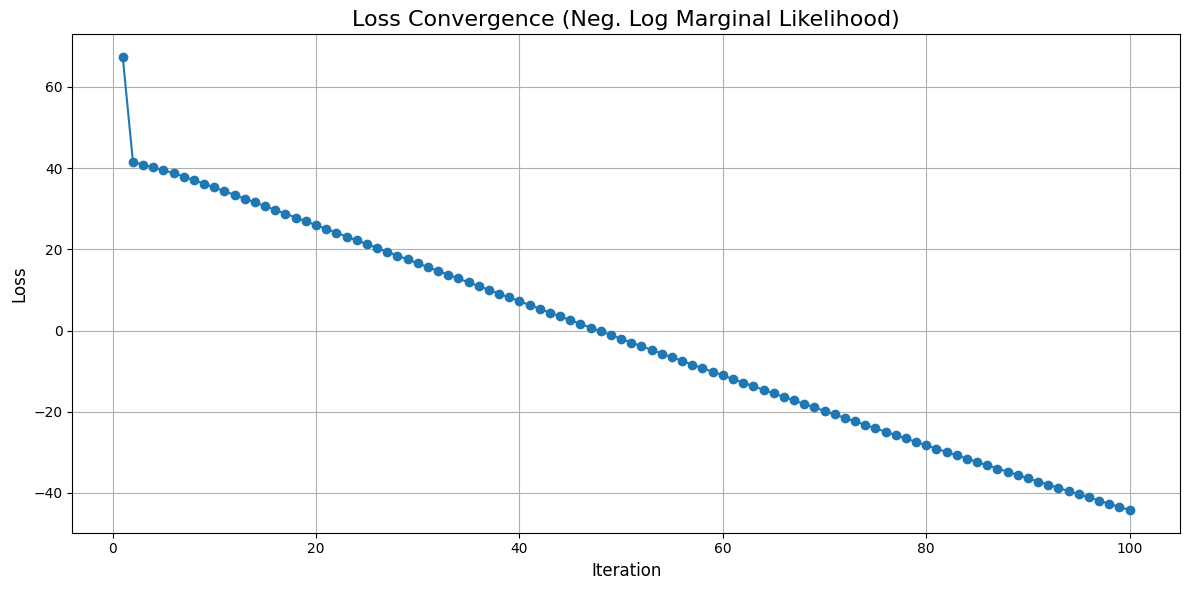

In [3]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm

# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)

class TPRT_Laplace(nn.Module):
    """
    Implements Student-t Process Regression with Student-t Likelihood (TPRT)
    using the Laplace Approximation method from Tang et al. (2017).
    """
    def __init__(self, X, y, nu_1=2.1, nu_2=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())

        self.N, self.D = X.shape

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_1 = nn.Parameter(torch.log(torch.tensor(nu_1)))
        self.log_nu_2 = nn.Parameter(torch.log(torch.tensor(nu_2)))

        # Buffer to store the mode of the latent function f
        self.register_buffer('f_hat', torch.zeros(self.N))


    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma = torch.exp(self.log_likelihood_sigma)
        nu_1 = torch.exp(self.log_nu_1)
        nu_2 = torch.exp(self.log_nu_2)
        return lengthscale, variance, sigma, nu_1, nu_2

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _calculate_ln_Q(self, f, K_inv, hyperparams):
        """Calculates the unnormalized posterior log density ln Q(f) = ln p(y|f) + ln p(f)."""
        _, _, sigma, nu_1, nu_2 = hyperparams
        # Log-likelihood term
        log_lik_term = ((nu_2 + 1) / 2) * torch.log(1 + (1 / nu_2) * ((self.y - f) / sigma).pow(2))
        # Log-prior term
        fT_K_inv_f = f @ K_inv @ f
        log_prior_term = ((nu_1 + self.N) / 2) * torch.log(1 + (1 / nu_1) * fT_K_inv_f)
        return torch.sum(log_lik_term) + log_prior_term

    def _find_f_hat(self, K_inv_detached, hyperparams_detached, max_iter=10, tol=1e-5):
        """
        Inner loop to find the mode f_hat for fixed, DETACHED hyperparameters using L-BFGS.
        This optimization is performed on a detached graph.
        """
        f = nn.Parameter(self.f_hat.clone())
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")

        def closure():
            optimizer.zero_grad()
            loss = self._calculate_ln_Q(f, K_inv_detached, hyperparams_detached)
            loss.backward()
            return loss

        for _ in range(max_iter):
            f_old = f.clone().detach()
            optimizer.step(closure)
            if torch.norm(f.detach() - f_old) < tol:
                break
        
        return f.detach()

    def _calculate_neg_log_marginal_likelihood(self):
        """
        Calculates the loss (negative log marginal likelihood) for hyperparameter optimization.
        This function builds the computation graph for the outer optimization loop.
        """
        hyperparams = self._get_hyperparams()
        _, _, sigma, nu_1, nu_2 = hyperparams

        # 1. Compute Kernel (this is part of the main computation graph)
        K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)

        # 2. Find the mode f_hat using a detached graph to prevent gradients from flowing
        #    through the inner optimization loop.
        with torch.no_grad():
            K_inv_detached = K_inv.detach()
            hyperparams_detached = tuple(p.detach() for p in hyperparams)
            f_hat = self._find_f_hat(K_inv_detached, hyperparams_detached)
            self.f_hat.copy_(f_hat) # Update buffer without creating a graph connection

        # --- Graph construction for the outer loop starts here ---
        # 3. Calculate ln(Q) at f = f_hat. This is connected to the graph via K_inv and hyperparams.
        ln_Q_at_f_hat = self._calculate_ln_Q(f_hat, K_inv, hyperparams)

        # 4. Calculate the Negative Hessian of ln(Q) at f_hat, denoted A_inv in the paper.
        f_hat_T_K_inv_f_hat = f_hat @ K_inv @ f_hat
        prior_hess_num = K_inv * (nu_1 + f_hat_T_K_inv_f_hat) - 2 * (K_inv @ torch.outer(f_hat, f_hat) @ K_inv)
        prior_hess_den = (nu_1 + f_hat_T_K_inv_f_hat)**2
        prior_hess = (nu_1 + self.N) * (prior_hess_num / prior_hess_den)

        err = self.y - f_hat
        lik_hess_num = err.pow(2) - nu_2 * sigma**2
        lik_hess_den = (err.pow(2) + nu_2 * sigma**2)**2
        W_diag = -(nu_2 + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag)
        A_inv = prior_hess + W

        # 5. Calculate log|B|, where B = K + A
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A_inv = torch.linalg.slogdet(A_inv)
        if sign.item() <= 0:
            # If Hessian is not positive definite, return a large loss
            return torch.tensor(float('inf'))

        log_det_B = log_det_K + log_det_A_inv

        # 6. Calculate constant terms from the marginal likelihood formula
        c_nu_1_term = torch.lgamma((nu_1 + self.N)/2) - torch.lgamma(nu_1/2) - (self.N/2)*torch.log(nu_1*math.pi)
        c_nu_2_term = self.N * (torch.lgamma((nu_2 + 1)/2) - torch.lgamma(nu_2/2) - 0.5*torch.log(nu_2*math.pi))
        c_sigma_term = -self.N * torch.log(sigma)

        # Combine all terms to get the final negative log marginal likelihood
        neg_log_marginal_lik = ln_Q_at_f_hat - 0.5 * log_det_B - (c_nu_1_term + c_nu_2_term + c_sigma_term)
        
        return neg_log_marginal_lik

    def fit(self, max_iter=100, lr=0.01):
        """
        Fits the model by minimizing the negative log marginal likelihood.
        Returns the history of the loss.
        """
        print("Starting hyperparameter optimization...")
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)
        loss_history = [] # ADDED: To store loss values

        for i in pbar:
            optimizer.zero_grad()
            loss = self._calculate_neg_log_marginal_likelihood()
            
            if torch.isinf(loss) or torch.isnan(loss):
                print(f"Warning: Loss is {loss.item()} at iteration {i}, skipping step.")
                # Optionally, revert to previous good parameters or reduce learning rate
                continue

            loss.backward()
            optimizer.step()
            
            loss_history.append(loss.item()) # ADDED: Store loss
            pbar.set_description(f"NegLogMargLik: {loss.item():.2f}")
        
        return loss_history # ADDED: Return history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            hyperparams = self._get_hyperparams()
            _, _, sigma, nu_1, nu_2 = hyperparams
            f_hat = self.f_hat

            # Precompute kernels
            K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()

            # Predictive mean
            pred_mean = K_star_x @ K_inv @ f_hat

            # Predictive variance
            f_hat_T_K_inv_f_hat = f_hat @ K_inv @ f_hat
            prior_hess_num = K_inv * (nu_1 + f_hat_T_K_inv_f_hat) - 2 * (K_inv @ torch.outer(f_hat, f_hat) @ K_inv)
            prior_hess_den = (nu_1 + f_hat_T_K_inv_f_hat)**2
            prior_hess = (nu_1 + self.N) * (prior_hess_num / prior_hess_den)
            
            err = self.y - f_hat
            lik_hess_num = err.pow(2) - nu_2 * sigma**2
            lik_hess_den = (err.pow(2) + nu_2 * sigma**2)**2
            W = torch.diag(-(nu_2 + 1) * (lik_hess_num / lik_hess_den))
            A_inv = prior_hess + W
            
            try:
                # Invert the negative Hessian to get the covariance matrix A
                L_A_inv = torch.linalg.cholesky(A_inv)
                A = torch.cholesky_inverse(L_A_inv)
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Using pseudo-inverse.")
                A = torch.linalg.pinv(A_inv)

            K_inv_k_star = torch.cholesky_solve(K_star_x.T, L)
            prior_var_reduction = (K_star_x * K_inv_k_star.T).sum(dim=1)
            posterior_uncertainty = (K_star_x @ K_inv @ A @ K_inv @ K_star_x.T).diag()
            
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9) # Ensure variance is non-negative
            
            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true + noise
    
    # Add significant outliers
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup the TPRT_Laplace model
    model = TPRT_Laplace(
        X=X_train,
        y=y_train,
        nu_1=2.1,
        nu_2=2.1,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model hyperparameters and get loss history
    # MODIFIED: Capture the returned loss_history
    loss_history = model.fit(max_iter=100, lr=0.01)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    # Using Gaussian assumption for confidence interval visualization
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title('TPRT with Laplace Approximation', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    l, v, s, n1, n2 = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {l.item():.3f}")
    print(f"Kernel Variance: {v.item():.3f}")
    print(f"Likelihood Sigma: {s.item():.3f}")
    print(f"Prior DoF (nu_1): {n1.item():.3f}")
    print(f"Likelihood DoF (nu_2): {n2.item():.3f}")
    
    # 6. ADDED: Visualize Loss (Negative Log Marginal Likelihood) history
    if loss_history: # Only plot if training happened
        plt.figure(figsize=(12, 6))
        plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', linestyle='-')
        plt.title('Loss Convergence (Neg. Log Marginal Likelihood)', fontsize=16)
        plt.xlabel('Iteration', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.grid(True)
        plt.tight_layout()

    plt.show()
